# Spark Session

In [2]:
from pyspark.sql import SparkSession


spark = SparkSession.builder \
    .config("spark.driver.memory", "5g") \
    .config("spark.executor.memory", "5g") \
    .appName("Open food facts") \
    .getOrCreate()

# Load the data
data = spark.read.csv(
    "/Users/mac/Desktop/Spark-Recommendation-System/data/final_data_cleaned.csv",
    header=True,
)

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/06/03 15:21:43 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
data.printSchema()

root
 |-- code: string (nullable = true)
 |-- url: string (nullable = true)
 |-- product_name: string (nullable = true)
 |-- generic_name: string (nullable = true)
 |-- quantity: string (nullable = true)
 |-- brands: string (nullable = true)
 |-- categories_tags: string (nullable = true)
 |-- categories_en: string (nullable = true)
 |-- ingredients_tags: string (nullable = true)
 |-- ingredients_analysis_tags: string (nullable = true)
 |-- additives_tags: string (nullable = true)
 |-- nutriscore_grade: string (nullable = true)
 |-- nova_group: string (nullable = true)
 |-- product_quantity: string (nullable = true)
 |-- main_category: string (nullable = true)
 |-- image_url: string (nullable = true)
 |-- custom_completeness: string (nullable = true)



# Data Analysis

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql.functions import col, split, explode

## Nutriscore Grade Distribution

25/06/03 15:21:58 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors
/var/folders/66/h72_j3k100q765kx5_dbc_900000gn/T/ipykernel_29812/2498279514.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=nutriscore_pd, x="nutriscore_grade", y="count", palette="viridis")


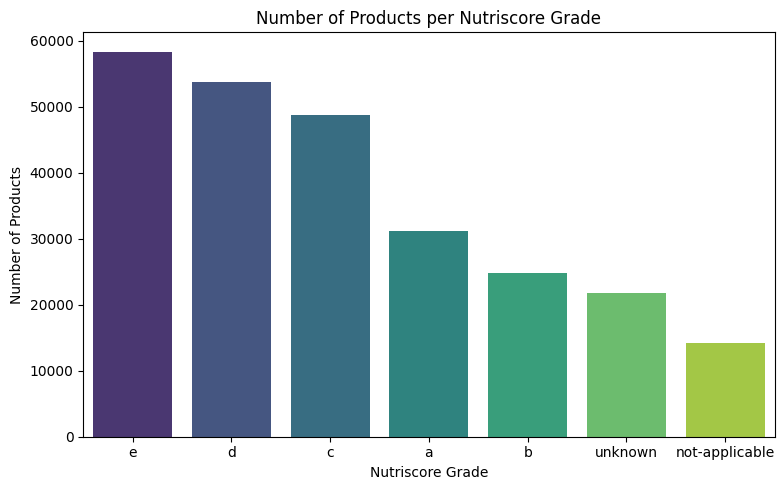

In [5]:
nutriscore_df = data.groupBy("nutriscore_grade").count().orderBy("count", ascending=False)
nutriscore_pd = nutriscore_df.toPandas()

plt.figure(figsize=(8,5))
sns.barplot(data=nutriscore_pd, x="nutriscore_grade", y="count", palette="viridis")
plt.title("Number of Products per Nutriscore Grade")
plt.xlabel("Nutriscore Grade")
plt.ylabel("Number of Products")
plt.tight_layout()
plt.show()

## Nova Group Distri

/var/folders/66/h72_j3k100q765kx5_dbc_900000gn/T/ipykernel_29812/1611314470.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=nova_pd, x="nova_group", y="count", palette="magma")


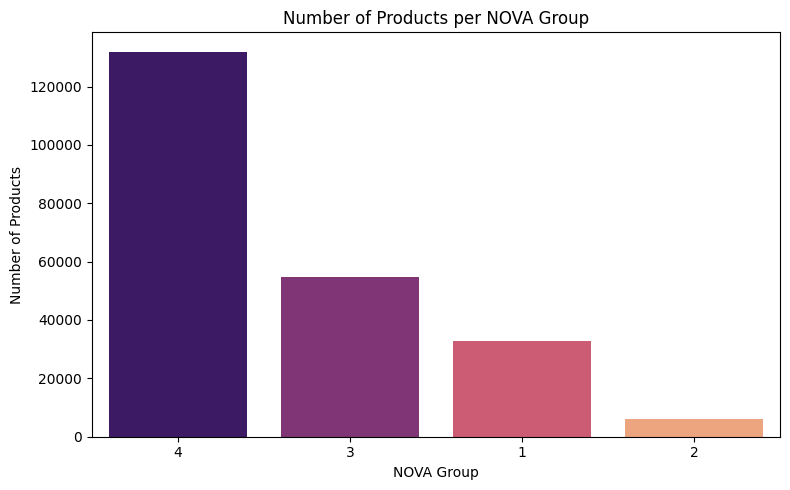

In [6]:
nova_df = data.groupBy("nova_group").count().orderBy("count", ascending=False)
nova_pd = nova_df.toPandas()

plt.figure(figsize=(8,5))
sns.barplot(data=nova_pd, x="nova_group", y="count", palette="magma")
plt.title("Number of Products per NOVA Group")
plt.xlabel("NOVA Group")
plt.ylabel("Number of Products")
plt.tight_layout()
plt.show()

/var/folders/66/h72_j3k100q765kx5_dbc_900000gn/T/ipykernel_29812/3224766651.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=categories_pd, x="count", y="category", palette="cubehelix")


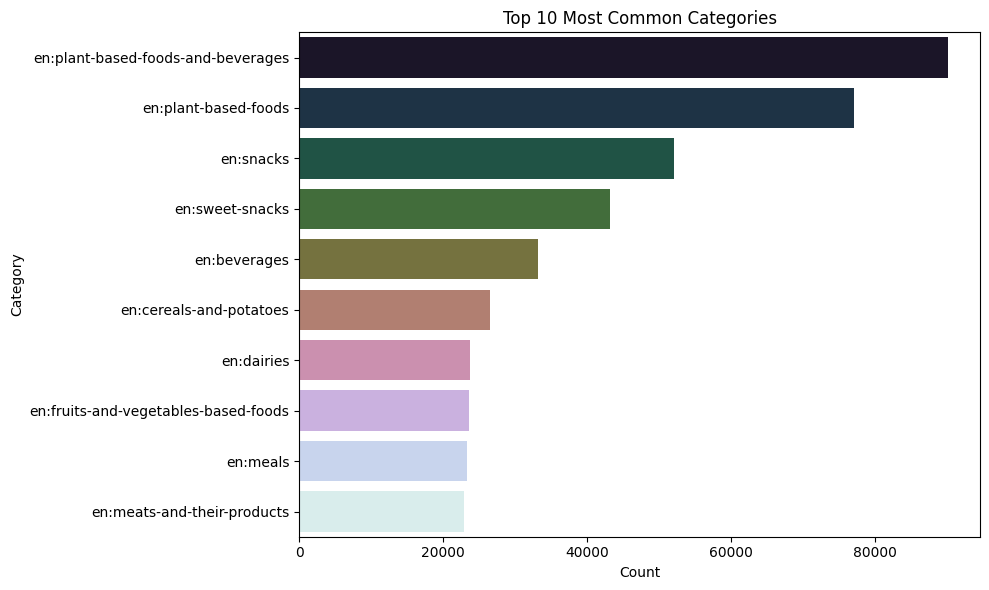

In [7]:
categories_df = data.withColumn("category", explode(split(col("categories_tags"), ","))) \
                  .groupBy("category") \
                  .count() \
                  .orderBy("count", ascending=False) \
                  .limit(10)

categories_pd = categories_df.toPandas()

plt.figure(figsize=(10,6))
sns.barplot(data=categories_pd, x="count", y="category", palette="cubehelix")
plt.title("Top 10 Most Common Categories")
plt.xlabel("Count")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

## Most common main category

/var/folders/66/h72_j3k100q765kx5_dbc_900000gn/T/ipykernel_29812/3736192463.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=main_cat_pd.head(20), y="main_category", x="count", palette="crest")


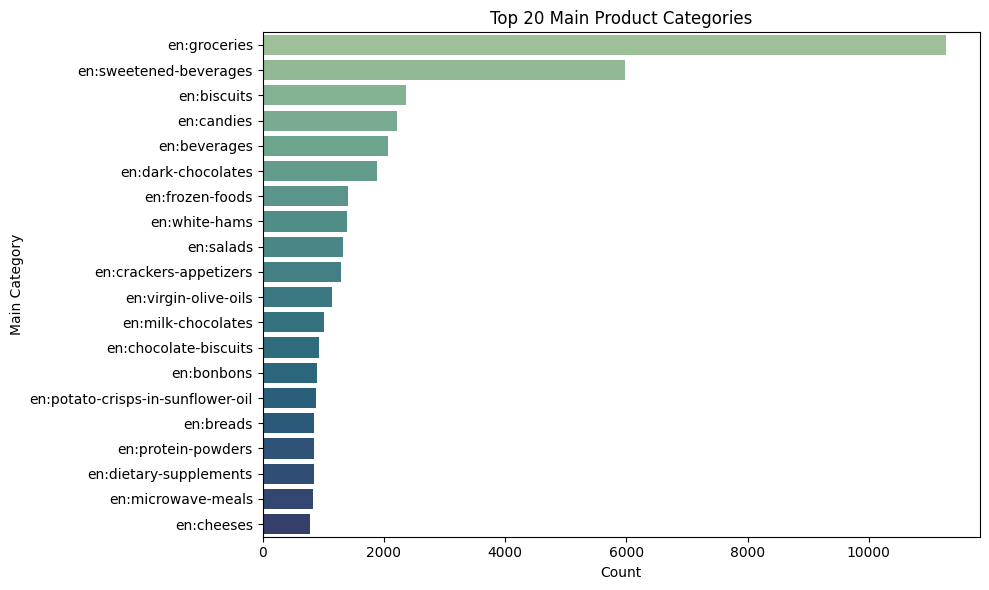

In [8]:
main_cat_df = data.groupBy("main_category").count().orderBy("count", ascending=False)
main_cat_pd = main_cat_df.toPandas()

plt.figure(figsize=(10,6))
sns.barplot(data=main_cat_pd.head(20), y="main_category", x="count", palette="crest")
plt.title("Top 20 Main Product Categories")
plt.xlabel("Count")
plt.ylabel("Main Category")
plt.tight_layout()
plt.show()


## Most frequent words in product name

/var/folders/66/h72_j3k100q765kx5_dbc_900000gn/T/ipykernel_29812/4112345938.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=product_terms_pd, x="count", y="word", palette="light:#5A9")


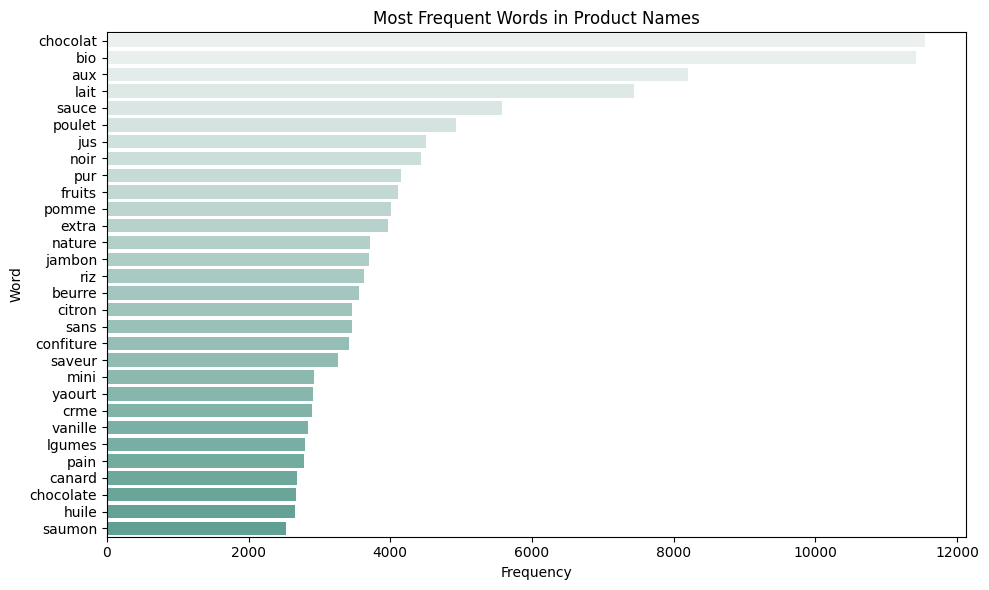

In [9]:
from pyspark.sql.functions import lower, regexp_replace, split, explode

product_terms_df = data.withColumn("product_name", lower(col("product_name"))) \
    .withColumn("word", explode(split(regexp_replace("product_name", "[^a-zA-Z ]", ""), "\\s+"))) \
    .groupBy("word").count().orderBy("count", ascending=False) \
    .filter(col("word").rlike("^[a-z]{3,}$"))  # ignore very short words or punctuation

product_terms_pd = product_terms_df.limit(30).toPandas()

plt.figure(figsize=(10,6))
sns.barplot(data=product_terms_pd, x="count", y="word", palette="light:#5A9")
plt.title("Most Frequent Words in Product Names")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.tight_layout()
plt.show()


In [10]:
df_with_count = data.withColumn("num_categories", size(split("categories_tags", ",")))

histogram_df = df_with_count.groupBy("num_categories").count().orderBy("num_categories")
histogram_pd = histogram_df.toPandas()

plt.bar(histogram_pd['num_categories'], histogram_pd['count'])
plt.xlabel("Number of Category Tags")
plt.ylabel("Number of Products")
plt.title("Distribution of Category Tags per Product")
plt.grid(True)
plt.show()


NameError: name 'size' is not defined